### **Import Preprocessing Libraries**
Import all preprocessing libraries that will be used in the code.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Load and Explore the Data**
To start, we load the Titanic dataset into a pandas DataFrame so we can start working with it. We also display the first few rows to get a quick look at what the data looks like and what kinds of features are included.

In [ ]:
# Load the dataset into a dataframe
df = pd.read_csv('/content/drive/MyDrive/Data Science Group Project- Titanic/Titanic-Dataset.csv')
df.head()

# Note: if the import doesn't work, since Catherine is the owner of the folder, you have to add it to your drive first
# Do this by going to the folder under Shared with Me, then right-click and click "Add shortcut to Drive" and then choose My Drive

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Justification:**

This step is important because it initializes the dataset and gives us an initial understanding of the structure, column names, and sample values before doing any preprocessing.

We check the structure of the dataset, including data types and non-null counts, to better understand what kind of data we're working with.

In [ ]:
# Check the size and structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Justification:**

This helps identify which columns are numerical vs categorical and highlights any missing values that will need to be handled later.

Next, we calculate how many missing values exist in each column so we can decide how to handle them.

In [ ]:
# Check how many missing values exist in each column
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Justification:**

Handling missing data is a key preprocessing step, and this gives us a clear view of which features need cleaning or imputation.

#### **Brief Dataset Description**

This dataset contains information about passengers aboard the Titanic and whether or not they survived the sinking. Each row represents a single passenger, and each column describes a different attribute of that passenger that could potentially influence survival.

The features included in the dataset are:
* `PassengerId`: A unique identifier assigned to each passenger (does not carry meaningful information for prediction)
* `Survived`: Whether the passenger survived (0 = No, 1 = Yes)
* `Pclass`: Ticket class, which can also be interpreted as a proxy for socioeconomic status (1 = 1st, 2 = 2nd, 3 = 3rd)
* `Name`: The full name of the passenger, which also contains useful embedded information such as titles
* `Sex`: Gender of the passenger (male or female)
* `Age`: Age of the passenger in years
* `SibSp`: Number of siblings or spouses aboard the Titanic
* `Parch`: Number of parents or children aboard the Titanic
* `Ticket`: Ticket number (mostly categorical/random values)
* `Fare`: The fare the passenger paid for their ticket
* `Cabin`: Cabin number of the passenger (if available)
* `Embarked`: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

In terms of structure, the dataset contains a mix of numerical and categorical features. The numerical features include `PassengerId`, `Pclass`, `Age`, `SibSp`, `Parch`, and `Fare`. Although `Survived` is stored as an integer, it is really a binary categorical variable representing survival. The remaining features (`Name`, `Sex`, `Ticket`, `Cabin`, and `Embarked`) are categorical/text-based.

One important thing we notice early on is the presence of missing values. `Cabin` has a very large number of missing values (687 out of 891), which suggests that this feature may not be very reliable. `Age` also has a significant number of missing values (177), while `Embarked` only has a small number missing (2). This means we will need to make thoughtful preprocessing decisions to handle missing data in a way that does not distort the dataset.

Overall, this dataset includes a mix of demographic, socioeconomic, and travel-related features, which gives us a good foundation for both clustering passengers and analyzing which factors are most associated with survival.

### **Visualize the Features**
We plot histograms for a few numeric features to see how their values are distributed.

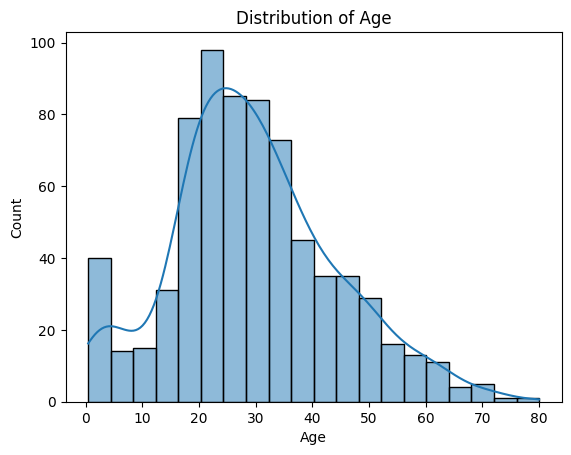

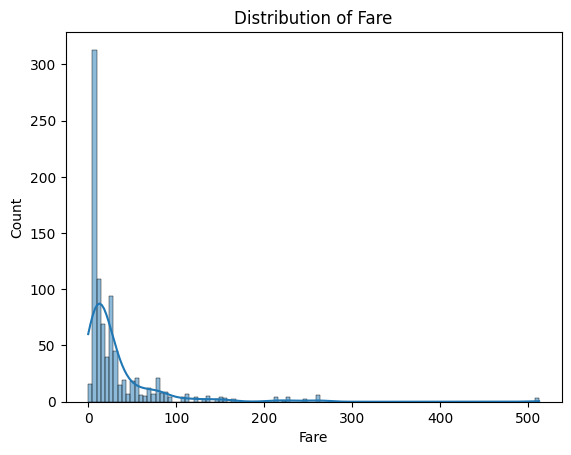

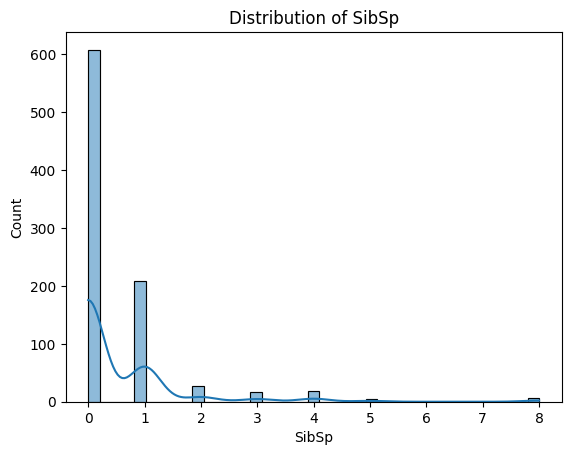

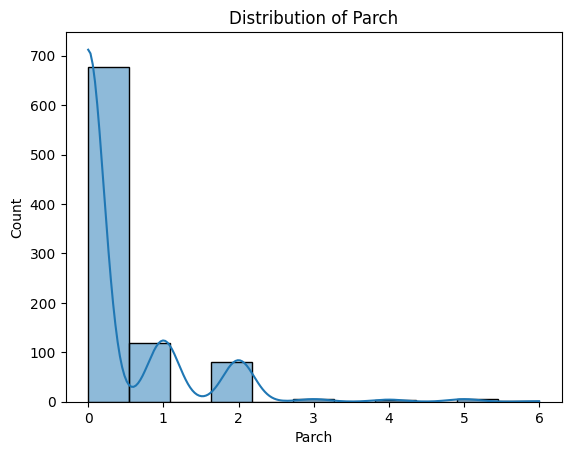

In [ ]:
# Plot distributions for a few numeric features to see how values are spread
numeric_features = ["Age", "Fare", "SibSp", "Parch"]

for col in numeric_features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

**Justification:**

This helps us understand skewness, outliers, and general patterns in the data, which can influence preprocessing decisions like scaling or transformations.

**Age Distribution Interpretation**

The distribution of age appears to be somewhat close to a normal distribution, but it is slightly skewed and not perfectly symmetric. We see that there is a noticeable concentration of passengers between the ages of about 15 and 35, with a peak around age 25. This suggests that a large portion of the passengers were young adults.
There is also a smaller spike among very young children (ages 0–5), which indicates that families with young children were present on board. After around age 35, the counts begin to steadily decrease, and there are very few passengers above age 60–70.

Overall, this tells us that the dataset is dominated by younger individuals, which could influence survival patterns. For example, if younger passengers were treated differently during evacuation, this distribution could impact our clustering and feature importance later.

**Fare Distribution Interpretation**

The fare distribution is highly right-skewed, meaning that most passengers paid relatively low fares, while a small number paid extremely high fares. There is a very large spike in the $5–$10 range, with over 300 passengers in that range, and then a gradual decrease as fares increase.
We also notice a few extreme outliers, with fares going above $500. These likely correspond to first-class passengers with very expensive accommodations.

This skewness indicates that fare is not evenly distributed and may strongly reflect passenger class and wealth. Because of this, fare could be a very important feature when analyzing survival, since higher-paying passengers may have had better access to lifeboats or priority treatment.

**Parch Distribution Interpretation**

Similar to `SibSp`, the `Parch` distribution is also highly right-skewed. Most passengers (close to 700) have 0 parents/children aboard, and then there are smaller counts for 1 and 2, with very few larger values.
This reinforces the idea that most passengers were not traveling with large family groups. Like SibSp, this feature may still be important, but its skewness suggests that combining it with other features (like we later do with FamilySize) could make it more meaningful.

I’m visualizing how survival differs between males and females and across different passenger classes.

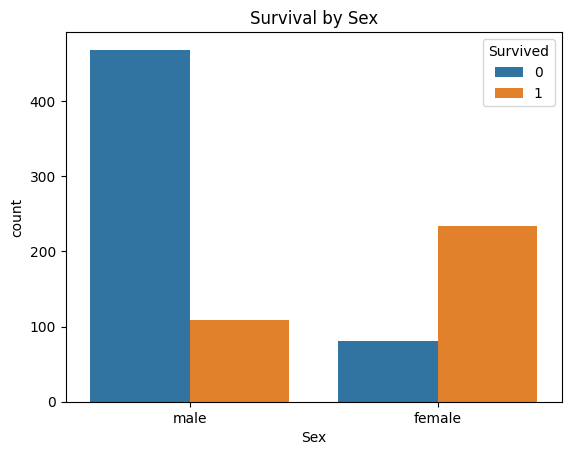

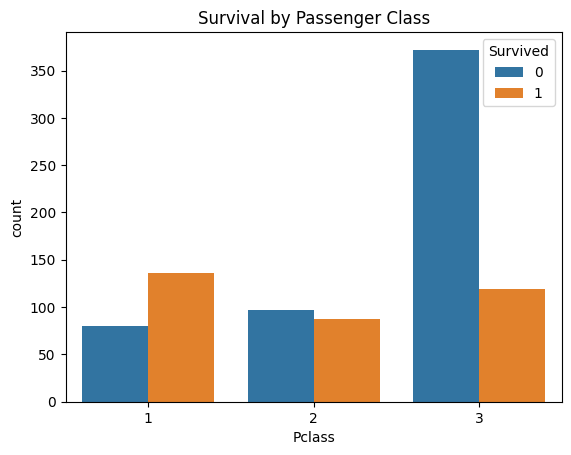

In [ ]:
# Look at how survival varies by sex
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Sex")
plt.show()

# Look at survival by passenger class
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

**Justification:**

The first graph gives insight into whether gender is an important predictor, which can inform feature selection later. The second graph helps confirm whether socioeconomic status (represented by class) is correlated with survival, which is historically known to be important in this dataset.

**Survival by Sex Interpretation**

From the graph, we can clearly see a strong imbalance in survival outcomes between males and females. For males, a large majority (over 450) did not survive, while only a relatively small number (just over 100) survived. In contrast, for females, the pattern is almost reversed, with significantly more surviving (around 225) than not surviving (under 100).
This indicates that gender was a very strong factor in determining survival, which aligns with the historical “women and children first” evacuation policy.

We also notice that the distribution between male and female passengers is not equal, which is important because it means the dataset itself is imbalanced. This imbalance needs to be kept in mind when interpreting results later, since it can influence clustering and model behavior.

**Survival by Passenger Class Interpretation**

The survival distribution across passenger classes also shows clear patterns. For first class, more passengers survived (around 140) than did not survive (around 80), suggesting a survival advantage. For second class, the distribution is more balanced, with slightly more not surviving than surviving. For third class, there is a large imbalance, with many more passengers not surviving (around 375) compared to those who survived (around 125).
This suggests that passenger class—and by extension, socioeconomic status—played a major role in survival outcomes.

Additionally, the number of passengers in each class is not evenly distributed, with third class having significantly more passengers than first or second class. This imbalance is important because it can affect clustering results and needs to be considered when interpreting patterns.

### **Handle Missing Values**
We drop the Cabin column because it has too many missing values, and then we fill missing values in Age and Embarked using reasonable defaults.

In [ ]:
# Cabin has too many missing values, so we will drop it
df = df.drop(columns=["Cabin"])

# Fill missing Age values with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the most common port
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
min_max = df.agg(['min', 'max'])
modes = df.mode().iloc[0].to_frame(name='mode').T
summary = pd.concat([min_max, modes])
print(summary)

     PassengerId Survived Pclass                         Name     Sex   Age  \
min            1        0      1          Abbing, Mr. Anthony  female  0.42   
max          891        1      3  van Melkebeke, Mr. Philemon    male  80.0   
mode           1      0.0    3.0          Abbing, Mr. Anthony    male  28.0   

     SibSp Parch     Ticket      Fare Embarked  
min      0     0     110152       0.0        C  
max      8     6  WE/P 5735  512.3292        S  
mode   0.0   0.0       1601      8.05        S  


**Justification:**

`Cabin` is dropped because it has an extremely high number of missing values (687 out of 891), meaning that the majority of the data for this feature is unavailable. Attempting to impute these values would likely introduce a large amount of noise or inaccurate assumptions, since there is not enough information to reliably infer the missing values. Because of this, keeping the Cabin feature could actually harm the quality of our analysis rather than help it.

For `Age`, we choose to fill missing values using the median instead of the mean. This is because the age distribution is somewhat skewed and contains outliers (especially at very young and very old ages). The median is more robust to these outliers and provides a more representative “typical” value for the dataset.

For `Embarked`, since it is a categorical feature with only a few missing values, we fill them using the mode (most common value). This is a reasonable assumption because the number of missing entries is very small, and using the most frequent category minimizes distortion to the overall distribution.

Overall, our goal with handling missing data is to preserve as much of the dataset as possible while avoiding introducing bias or misleading patterns that could negatively impact clustering and feature analysis.

### **Log Transform Fare**
Since Fare is highly right-skewed, we apply a log transformation to compress large values and make the distribution more normal. This helps reduce the influence of extreme values without removing them.

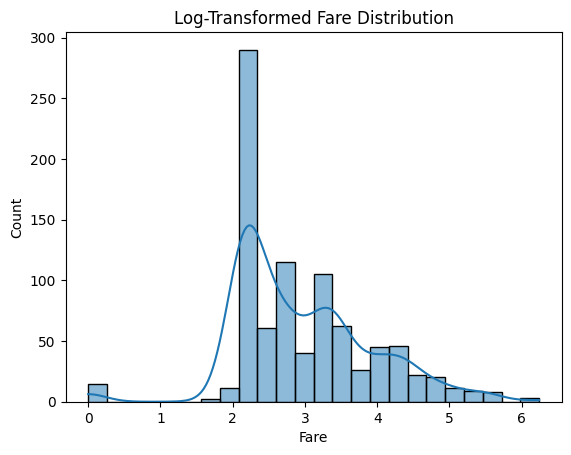

In [ ]:
# Apply log transformation to reduce skewness in Fare
df["Fare"] = np.log1p(df["Fare"])

# Visualize the new distribution
plt.figure()
sns.histplot(df["Fare"], kde=True)
plt.title("Log-Transformed Fare Distribution")
plt.show()

**Justification:**

We use log1p (log(1 + x)) instead of a regular log to handle zero values safely. This transformation reduces the impact of very large fares while preserving the relative differences between passengers. This is especially important for clustering, since extreme values can distort distance calculations and dominate the grouping process.

After applying the log transformation to the `Fare` feature, we observed that the distribution became significantly more normalized and the extreme right skew was greatly reduced. The previously large values that appeared as outliers were compressed into a more reasonable range, and the histogram no longer showed any clearly isolated or extreme points. Because of this, we determined that there were no longer any true outliers that would disproportionately influence the model.

### **Create New Features: FamilySize and Title**
We create a new feature called FamilySize by combining SibSp and Parch, since both relate to family relationships.

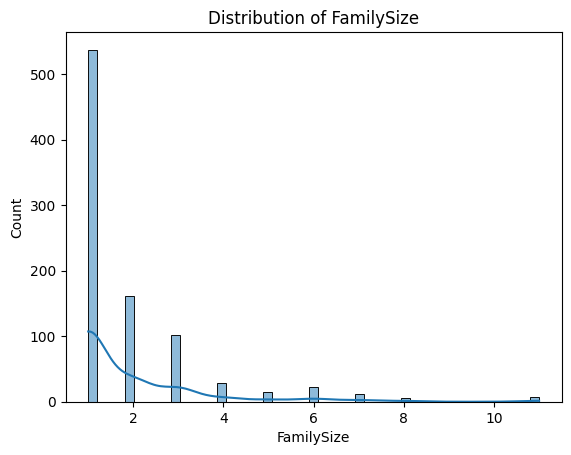

In [ ]:
# Create a family size feature since SibSp and Parch both represent family relationships
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
plt.figure()
sns.histplot(df["FamilySize"], kde=True)
plt.title(f"Distribution of FamilySize")
plt.show()

**Justification:**

We create a new feature called `FamilySize` by combining `SibSp` and `Parch` (and adding 1 to include the passenger themselves). While `SibSp` and `Parch` separately represent different types of family relationships, they both essentially capture whether a passenger is traveling with family and how large that group is. By combining them into a single feature, we simplify the dataset and create a more meaningful representation of family presence. Instead of treating siblings/spouses and parents/children separately, we now have a unified measure of total family size, which is likely more directly related to behavior and survival outcomes.

This is especially useful for clustering, because reducing multiple related features into one helps lower dimensionality and makes patterns easier for the model to detect. It also reduces redundancy, since `SibSp` and `Parch` are somewhat correlated.

**FamilySize Distribution Interpretation**

The FamilySize distribution is also right-skewed, with the majority of passengers having a family size of 1 (meaning they are traveling alone). As family size increases, the number of passengers decreases significantly.
This indicates that most passengers were traveling alone, while only a smaller number were traveling in larger family groups. The few larger family sizes (5 and above) are quite rare.

This pattern suggests that being alone versus being in a group could be an important factor in survival. For example, individuals traveling alone may have had more flexibility, while those in larger groups may have faced different challenges. This makes FamilySize a potentially meaningful feature for both clustering and survival analysis.

We extract titles (like Mr, Mrs, Miss, and Master) from the Name column and then group rare titles together to simplify the feature.

In [ ]:
# Extract titles like Mr, Mrs, Miss from the name column
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
print("Before:", df["Title"].unique())

# Group rare titles into a single category to simplify the feature
rare_titles = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]

df["Title"] = df["Title"].replace(rare_titles, "Rare")
df["Title"] = df["Title"].replace({"Mlle":"Miss", "Ms":"Miss", "Mme":"Mrs"})

print("After:", df["Title"].unique())

Before: ['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']
After: ['Mr' 'Mrs' 'Miss' 'Master' 'Rare']


**Justification:**

We extract titles (such as Mr, Mrs, Miss, and Master) from the Name column because they contain useful social and demographic information that is not explicitly captured in other features. For example, titles can give insight into gender, age group (e.g., “Master” often refers to young boys), and social status. However, there are many rare titles in the dataset (such as “Lady,” “Countess,” etc.), and if we keep them all as separate categories, this would create a very sparse feature when encoding. Sparse features can negatively impact clustering because they introduce noise and make it harder for the model to identify meaningful groupings.
To address this, we group rare titles into a single category called “Rare.” This reduces the number of unique categories and helps prevent overfitting, while still preserving the general signal that these uncommon titles represent.

This preprocessing step is especially important for encoding and clustering, because it ensures that the feature remains informative without unnecessarily increasing dimensionality.

### **Remove Unnecessary Features**
We remove columns that won’t help with prediction or have already been transformed.

In [ ]:
# Drop columns that aren't helpful for modeling:
# - PassengerId is just an identifier
# - Ticket is mostly random codes
# - Name was already used to extract title

df = df.drop(columns=["PassengerId", "Ticket", "Name"])

df.shape

(891, 10)

**Justification:**

Dropping `PassengerId`, `Ticket`, and `Name` is an important preprocessing step because these features do not provide meaningful or usable information for our clustering task, and keeping them could actually introduce noise or distort the results.

First, `PassengerId` is simply a unique identifier assigned to each passenger. It does not carry any real-world meaning or relationship to survival or passenger characteristics. If we were to keep it in the dataset, especially after scaling, the model might still treat it as a numerical feature and try to find patterns in it, even though those patterns would be completely arbitrary. This could negatively impact clustering by introducing artificial structure that does not actually exist.

Next, the `Ticket` feature is mostly made up of alphanumeric codes that do not have a clear or consistent structure. While there may be some hidden meaning (such as grouping passengers who booked together), the feature is highly inconsistent and would be very difficult to encode in a meaningful way without extensive feature engineering. If we were to include it as-is, it would either greatly increase dimensionality (if one-hot encoded) or introduce misleading relationships (if label encoded). Because of this, we determined that the cost of including `Ticket` outweighs its potential benefit.

Finally, the `Name` column is removed because we have already extracted the most useful information from it in the form of the `Title` feature. The remaining parts of the name (such as last names) are highly unique and would not generalize well for clustering. Keeping the full `Name` column would significantly increase dimensionality without adding meaningful signal, especially since clustering benefits from more generalized patterns rather than highly specific identifiers.

Overall, removing these columns helps simplify the dataset, reduce dimensionality, and prevent the model from learning patterns based on irrelevant or overly specific information. This is especially important for clustering, where the goal is to group similar passengers based on meaningful features, rather than noise or arbitrary identifiers.

### **Feature Encoding**
We convert categorical variables into numerical format using one-hot encoding.

In [ ]:
# One Hot encoding
categorical_cols = ["Sex", "Embarked", "Title"]

df = pd.get_dummies(df, columns=categorical_cols)

# Check new dimensions
df.shape

(891, 17)

**Justification:**

Most machine learning models require numerical input, so we need to convert categorical features into a numerical format. Initially, we experimented with label encoding, where each category is assigned a number (e.g., 1, 2, 3). However, this approach introduced an artificial sense of order between categories that does not actually exist.
For example, if categories are encoded as 1, 2, and 3, the model may interpret category 2 as being “between” 1 and 3, which can distort relationships. We observed this issue in our clustering results, where the clusters appeared artificially “striped,” suggesting that the encoding was influencing the structure in an unintended way.

To fix this, we switched to one-hot encoding. This approach creates a separate binary column for each category, where each column simply indicates the presence (1) or absence (0) of that category. This avoids introducing any false ordering and allows each category to be treated independently.

This is especially important for clustering, because clustering algorithms rely on distance calculations. If categorical features are improperly encoded, it can significantly distort those distances and lead to misleading clusters. One-hot encoding ensures that the structure of the data is preserved in a more meaningful way.

In [ ]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,1,0,2.110213,2,False,True,False,False,True,False,False,True,False,False
1,1,1,38.0,1,0,4.280593,2,True,False,True,False,False,False,False,False,True,False
2,1,3,26.0,0,0,2.188856,1,True,False,False,False,True,False,True,False,False,False
3,1,1,35.0,1,0,3.990834,2,True,False,False,False,True,False,False,False,True,False
4,0,3,35.0,0,0,2.202765,1,False,True,False,False,True,False,False,True,False,False


### **Scale the Features**
We separate features and target, then scale the features so they are on the same scale.

In [ ]:
# Scaling

# Separate features and target
X = df.drop(columns=["Survived"])
y = df["Survived"]

# Standardize the features so they are on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to dataframe
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

**Justification:**

Scaling ensures that features with larger values don’t dominate the model. This is especially important for distance-based models and helps improve overall model performance.

### **Calculate Mutual Information Scores**

We calculate mutual information scores to measure how useful each feature is for predicting survival.

In [ ]:
# Use mutual information to determine how useful each feature is for predicting survival
mi_scores = mutual_info_classif(X_scaled, y, random_state=42) # Random state ensures that we get the same results every time

mi_results = pd.Series(mi_scores, index=X_scaled.columns).sort_values(ascending=False)

mi_results

,0
Sex_female,0.155781
Sex_male,0.151281
Fare,0.135930
Title_Mr,0.133898
Pclass,0.068077
FamilySize,0.047387
Title_Miss,0.046853
Title_Mrs,0.046126
SibSp,0.034920
Parch,0.024471


**Justification:**

Mutual information captures both linear and non-linear relationships, making it a strong choice for feature selection. Setting a random state ensures reproducibility.

We visualize the mutual information scores to better understand feature importance.

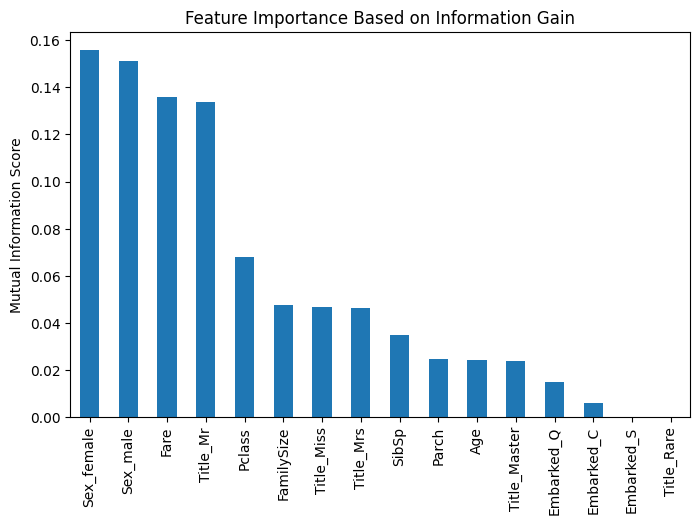

In [ ]:
# Plot information gain scores
plt.figure(figsize=(8,5))
mi_results.plot(kind="bar")
plt.title("Feature Importance Based on Information Gain")
plt.ylabel("Mutual Information Score")
plt.show()

**Justification:**

This makes it easier to interpret which features are most useful and provides a clear basis for deciding which features to drop.

**Mutual Information Score Interpretation**

The mutual information results show how much each feature contributes to predicting survival. We can see that features related to gender (`Sex_female` and `Sex_male`) have the highest scores, which confirms our earlier observation from the visualization that gender is a very strong predictor of survival.

Fare and titles (especially `Title_Mr`) also have relatively high scores, suggesting that socioeconomic status and social roles played an important role. `Pclass` and `FamilySize` have moderate importance, indicating that class and family structure also influence survival, but not as strongly as gender.

On the lower end, features like `Embarked_C`, `Embarked_S`, and `Title_Rare` have very low or even zero mutual information scores. This suggests that they do not provide meaningful information for predicting survival in this dataset.

We remove features that have very low mutual information scores.

In [ ]:
# Drop features that have very low information gain
low_info_features = mi_results[mi_results < 0.02].index
df_reduced = df.drop(columns=low_info_features)
print("Removed Features:", list(low_info_features))

Removed Features: ['Embarked_Q', 'Embarked_C', 'Embarked_S', 'Title_Rare']


**Justification:**

Removing low-value features helps reduce noise and prevents the model from learning irrelevant or misleading patterns. If we include too many weak or irrelevant features, the clustering algorithm may struggle to find clear groupings because the signal is diluted by noise.

We chose a threshold of 0.02 for mutual information because it provides a good balance between removing clearly uninformative features and retaining enough features to preserve meaningful structure in the data. Features with scores close to zero contribute little to no useful information, so removing them helps simplify the dataset without losing important insights. At the same time, we did not want to be too aggressive with feature removal, since clustering relies on multiple dimensions to identify patterns. By setting the threshold at 0.02, we ensure that we keep moderately informative features while eliminating those that are essentially irrelevant.

Overall, this step helps improve the quality of our clustering by focusing on the most meaningful features and reducing unnecessary complexity.

### **Final Processed Dataset**

We display the final processed dataset and its shape.

In [ ]:
# Final dataset after preprocessing:
print("Final dataset shape:", df_reduced.shape)

df_reduced.head()

Final dataset shape: (891, 13)


,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_female,Sex_male,Title_Master,Title_Miss,Title_Mr,Title_Mrs
0,0,3,22.0,1,0,2.110213,2,False,True,False,False,True,False
1,1,1,38.0,1,0,4.280593,2,True,False,False,False,False,True
2,1,3,26.0,0,0,2.188856,1,True,False,False,True,False,False
3,1,1,35.0,1,0,3.990834,2,True,False,False,False,False,True
4,0,3,35.0,0,0,2.202765,1,False,True,False,False,True,False


**Justification:**
This confirms that all preprocessing steps worked as expected and shows the final structure before modeling.

We save the cleaned dataset to the drive so we can reuse it in the clustering analysis without repeating preprocessing.

In [ ]:
# Save to drive in case it is easier to do analysis in a separate folder
df_reduced.to_csv('/content/drive/MyDrive/Data Science Group Project- Titanic/Titanic-Dataset-reduced.csv', index=False)